In [ ]:
import numpy as np
from scipy.optimize import brentq, minimize
from scipy.integrate import quad
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings; warnings.filterwarnings('ignore')

In [ ]:
plt.rcParams.update({'font.size': 9, 'axes.titlesize': 9, 'axes.labelsize': 9,
                     'xtick.labelsize': 8, 'ytick.labelsize': 8, 'figure.dpi': 150})

In [ ]:
rho = 7850.0;  E = 200e9;  D = 0.050;  L = 0.400
R  = D/2; A1 = np.pi*R**2; I1 = np.pi*R**4/4; Ip1 = np.pi*R**4/2
EI1 = E*I1; rhoA1 = rho*A1; rhoI1 = rho*I1; rhoIp1 = rho*Ip1
zeta0 = 0.01
Lr = 0.040
a_hol = 0.172; b_hol = 0.282; d_in = 0.025; R_in = d_in/2
A2 = np.pi*(R**2 - R_in**2); I2 = np.pi*(R**4 - R_in**4)/4; Ip2 = np.pi*(R**4 - R_in**4)/2
zd = 0.227
zf = L
Nt = 5; Ktc = 800e6; Krc = 200e6; ratio_kr = Krc / Ktc
damperrho=15000.0
dampermass=damperrho*np.pi*((R_in-0.5)**2)*(b_hol-a_hol-1)
md = 0.62;  kd_opt = 2.1e6;  cd_opt = 444.0 #md here is selected from density of absorber material and volume occupied by it

#Modal mass calculation with mode shapes

In [ ]:
#Characteristic euation calculation
def char_eq_solid(b): return np.cos(b*L)*np.cosh(b*L) + 1.0
scan = np.linspace(0.5, 50, 200000); vals = np.array([char_eq_solid(b) for b in scan])
betas1 = []
for i in range(len(vals)-1):
    if vals[i]*vals[i+1] < 0:
        betas1.append(brentq(char_eq_solid, scan[i], scan[i+1]))
    if len(betas1) >= 1: break
b1 = betas1[0]
wn1 = b1**2 * np.sqrt(EI1/rhoA1)
fn1 = wn1/(2*np.pi)
print(f"1st mode: beta1={b1:.5f}, fn={fn1:.2f} Hz (paper: ~306 Hz)")

sigma1 = (np.cosh(b1*L) + np.cos(b1*L)) / (np.sinh(b1*L) + np.sin(b1*L))
def psi(z): return np.cosh(b1*z)-np.cos(b1*z)-sigma1*(np.sinh(b1*z)-np.sin(b1*z))
def dpsi(z): return b1*(np.sinh(b1*z)+np.sin(b1*z))-sigma1*b1*(np.cosh(b1*z)-np.cos(b1*z))

psi_L = psi(L)
def PSI(z):  return psi(z)/psi_L
def dPSI(z): return dpsi(z)/psi_L

Mm,_  = quad(lambda z: rhoA1*PSI(z)**2, 0, L)
Rii,_ = quad(lambda z: rhoI1*dPSI(z)**2, 0, L)
Gii,_ = quad(lambda z: rhoIp1*dPSI(z)**2, 0, L)
Km = wn1**2 * Mm
Cm_visc = 2*zeta0*wn1*Mm

PSI_zd = PSI(zd); PSI_zf = PSI(zf)
print(f"Mm={Mm:.4f} kg (paper: 1.4146), PSI_zd={PSI_zd:.4f}, PSI_zf={PSI_zf:.4f}")
print(f"Rii={Rii:.6f}, Gii={Gii:.6f}")

1st mode: beta1=4.68776, fn=220.67 Hz (paper: ~306 Hz)
Mm=1.5413 kg (paper: 1.4146), PSI_zd=0.4205, PSI_zf=1.0000
Rii=0.006996, Gii=0.013992


#Building of Matrices

In [ ]:
def build_matrices(Omega=0, with_absorber=False, kd=0., cd=0., md_=0.,
                   cor=True, gyro=True, cent=True, rot_in=True):

  """
  Build M_eff, D_eff, K_eff for Eq.(28).
  State order (with absorber): [qui, ud, qvi, vd]
  Without absorber: [qui, qvi]
  """
  # Beam modal parameters at this speed
  M_beam = Mm + (Rii if rot_in else 0)
  K_beam = Km - (Omega**2 * Mm if cent else 0)
  # Coriolis+Gyro coupling: 2*Omega*(rhoA*int(psi^2) - rhoIp*beta^2*int(dpsi^2))
  # From Eq.(24)-(25): +2*Omega*rhoA*int(psi^2)*dq_v - 2*Omega*rhoIp*beta^2*int(dpsi^2)*dq_v
  # Net off-diagonal damping coeff = 2*Omega*(Mm - Gii)  [Mm = rhoA*int(psi^2)]
  C_cor = (2*Omega*Mm if cor else 0)
  C_gyr = (2*Omega*Gii if gyro else 0)
  C_off = C_cor - C_gyr   # net coupling (positive in upper triangle for u->v coupling)

  if not with_absorber:
      M_eff = np.array([[M_beam, 0],[0, M_beam]])
      D_eff = np.array([[Cm_visc,  C_off],
                        [-C_off, Cm_visc]])
      K_eff = np.array([[K_beam, 0],[0, K_beam]])
      return M_eff, D_eff, K_eff

  # With absorber: 4x4
  # Absorber centrifugal: -md*Omega^2 acts as stiffness reduction on absorber
  K_abs_cent = -(Omega**2 * md_ if cent else 0)
  # Absorber Coriolis coupling: 2*md*Omega (off-diagonal in absorber sub-block)
  C_abs_cor = (2*Omega*md_ if cor else 0)

  # [M]
  M_eff = np.diag([M_beam, md_, M_beam, md_])

  # [K]: coupling between beam modal coord and absorber displacement
  # From Eq.(26)-(27): kd*(ud - PSI_zd*qui) etc.
  M_eff = np.array([
      [M_beam, 0,       0,       0],
      [0,      md_,     0,       0],
      [0,      0,       M_beam,  0],
      [0,      0,       0,       md_]
  ])
  K_eff = np.array([
      [K_beam + kd*PSI_zd**2, -kd*PSI_zd,          0,                     0],
      [-kd*PSI_zd,            kd + K_abs_cent,      0,                     0],
      [0,                     0,                    K_beam + kd*PSI_zd**2, -kd*PSI_zd],
      [0,                     0,                    -kd*PSI_zd,            kd + K_abs_cent]
  ])
  D_eff = np.array([
      [Cm_visc + cd*PSI_zd**2, -cd*PSI_zd,          C_off,      0],
      [-cd*PSI_zd,              cd,                  0,          C_abs_cor],
      [-C_off,                  0,                   Cm_visc + cd*PSI_zd**2, -cd*PSI_zd],
      [0,                      -C_abs_cor,           -cd*PSI_zd, cd]
  ])
  return M_eff, D_eff, K_eff

#Natural Frequency for speed range

In [ ]:
def nat_freqs_vs_speed(speeds_rpm, **kwargs):
    """Returns list of natural freq lists (Hz) for each speed."""
    result = []
    for rpm in speeds_rpm:
        Omega = rpm*2*np.pi/60
        M,D,K = build_matrices(Omega, **kwargs)
        n = M.shape[0]
        # Companion: λ*[M 0; 0 I][x;y] = [-D -K; I 0][x;y]  → λx = Ax
        A = np.zeros((2*n, 2*n))
        Minv = np.linalg.inv(M)
        A[:n, :n] = -Minv @ D
        A[:n, n:] = -Minv @ K
        A[n:, :n] = np.eye(n)
        evs = np.linalg.eigvals(A)
        freqs = sorted(set(np.round(np.abs(evs.imag)/(2*np.pi), 2)))
        freqs = [f for f in freqs if f > 5]
        result.append(freqs)
    return result

In [ ]:
speeds_fig2 = np.linspace(0, 25000, 350)
print("Fig.2: computing natural freqs vs speed...")
f_cor  = nat_freqs_vs_speed(speeds_fig2, cor=True,  gyro=False, cent=False, rot_in=False)
f_gyro = nat_freqs_vs_speed(speeds_fig2, cor=False, gyro=True,  cent=False, rot_in=False)
f_cent = nat_freqs_vs_speed(speeds_fig2, cor=False, gyro=False, cent=True,  rot_in=False)
f_all  = nat_freqs_vs_speed(speeds_fig2, cor=True,  gyro=True,  cent=True,  rot_in=True)
print("Done.")

Fig.2: computing natural freqs vs speed...
Done.


In [ ]:
def extract_fw_bw(freqs_list, fmin=10, fmax=1500):
    """Extract forward (upper) and backward (lower) branches."""
    fw, bw = [], []
    for flist in freqs_list:
        in_rng = sorted([f for f in flist if fmin < f < fmax])
        if len(in_rng) >= 2:
            bw.append(in_rng[0]); fw.append(in_rng[-1])
        elif len(in_rng) == 1:
            bw.append(in_rng[0]); fw.append(in_rng[0])
        else:
            bw.append(np.nan); fw.append(np.nan)
    return np.array(fw), np.array(bw)

#FRF computation

In [ ]:
def compute_FRF(freqs_hz, Omega, **kwargs):
    """Return direct (Hxx) and cross (Hxy) FRF arrays (m/N)."""
    M,D,K = build_matrices(Omega, **kwargs)
    n = M.shape[0]
    Hxx = np.zeros(len(freqs_hz), dtype=complex)
    Hxy = np.zeros(len(freqs_hz), dtype=complex)

    # Force vector columns (in modal space):
    # x-force: f = [PSI_zf, 0, ...] for without absorber, [PSI_zf, 0, 0, 0] with
    # y-force: f = [0, ..., PSI_zf, 0]
    f_x = np.zeros(n); f_x[0] = PSI_zf
    f_y = np.zeros(n); f_y[n//2] = PSI_zf

    for k, f in enumerate(freqs_hz):
        w = 2*np.pi*f
        Z = (-w**2)*M + (1j*w)*D + K
        #print(Z)
        try:
            H = np.linalg.solve(Z, np.eye(n))
            # Physical response at zf (=L, PSI=1):
            # u(zf) = PSI_zf * qui  → PSI_zf * H[0,:] * f
            Hxx[k] = PSI_zf * (H[0,:] @ f_x)
            Hxy[k] = PSI_zf * (H[0,:] @ f_y)
        except:
            pass
    return Hxx, Hxy

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 6.  FRF AT A SINGLE CHATTER FREQUENCY
# ═══════════════════════════════════════════════════════════════════════════

def frf_at_wc(wc_rad, M, D, K):
    """
    Return H_xx and H_xy at angular frequency wc_rad.
    H_xx = ψ(zf)·[Z⁻¹]₀₀·ψ(zf),  H_xy = ψ(zf)·[Z⁻¹]₀,ₙ/₂·ψ(zf)
    """
    n  = M.shape[0]
    nb = n // 2
    fx = np.zeros(n);  fx[0]  = PSI_zf
    fy = np.zeros(n);  fy[nb] = PSI_zf
    Z  = -wc_rad**2 * M + 1j * wc_rad * D + K
    try:
        H   = np.linalg.solve(Z, np.column_stack([fx, fy]))
        hxx = PSI_zf * H[0, 0]
        hxy = PSI_zf * H[0, 1]
        return hxx, hxy
    except np.linalg.LinAlgError:
        return 0.0 + 0j, 0.0 + 0j

In [ ]:
#--------------------------------
#  FRF for no absorber
#--------------------------------
freqs_frf = np.linspace(50, 520, 1200)
speeds_fig3 = [0, 1000, 2000, 3000, 4000, 5000, 6000]
print("Fig.3: computing FRFs without absorber...")
FRF_d_noabs, FRF_c_noabs = [], []
for rpm in speeds_fig3:
    Hxx, Hxy = compute_FRF(freqs_frf, rpm*2*np.pi/60, with_absorber=False)
    FRF_d_noabs.append(np.abs(Hxx)); FRF_c_noabs.append(np.abs(Hxy))
print("Done.")

Fig.3: computing FRFs without absorber...
Done.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 7.  DIRECTIONAL COEFFICIENTS — Altintas 2012 averaging
# ═══════════════════════════════════════════════════════════════════════════

def directional_coefficients(case="up50"):
    if   case == "up50": phi1, phi2 = 0.0, np.pi / 2.0
    elif case == "slot": phi1, phi2 = 0.0, np.pi
    else:
        raise ValueError(case)
    phi   = np.linspace(phi1, phi2, 100_000)
    fx_fac = -np.cos(phi) - ratio_kr * np.sin(phi)
    fy_fac =  np.sin(phi) - ratio_kr * np.cos(phi)
    axx = np.trapezoid(np.sin(phi) * fx_fac, phi)
    axy = np.trapezoid(np.cos(phi) * fx_fac, phi)
    ayx = np.trapezoid(np.sin(phi) * fy_fac, phi)
    ayy = np.trapezoid(np.cos(phi) * fy_fac, phi)
    return axx, axy, ayx, ayy
axx_up, axy_up, ayx_up, ayy_up = directional_coefficients('up50')
axx_sl, axy_sl, ayx_sl, ayy_sl = directional_coefficients('slot')
print(f"Dir. coeffs up_50: axx={axx_up:.4f}, axy={axy_up:.4f}, ayx={ayx_up:.4f}, ayy={ayy_up:.4f}")
print(f"Dir. coeffs slot:  axx={axx_sl:.4f}, axy={axy_sl:.4f}, ayx={ayx_sl:.4f}, ayy={ayy_sl:.4f}")

Dir. coeffs up_50: axx=-0.6963, axy=-0.9104, ayx=0.6604, ayy=0.3037
Dir. coeffs slot:  axx=-0.3927, axy=-1.5708, ayx=1.5708, ayy=-0.3927


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 8.  STABILITY LOBE DIAGRAM — FULL Budak-Altintas algorithm
# ═══════════════════════════════════════════════════════════════════════════
# ALGORITHM (per Budak-Altintas 1995 / Altintas 2012 §4):
#
# For each chatter frequency ωc:
#  (a) Build FRF H(ωc) at the relevant speed (zero OR speed-dependent)
#  (b) Form  [Hor] = [α] · [H(ωc)]  and solve eigenvalue problem:
#      det([I] + Λ·[Hor]) = 0  →  Λ  (eigenvalue, 2×2 → quadratic)
#  (c) Pick the Λ with Re(Λ) < 0 (unstable side)
#  (d) Compute critical depth:
#      a_lim = −2π Re(Λ) / [Nt Ktc (1 + κ²)],  κ = Im(Λ)/Re(Λ)
#  (e) Phase shift: ε = π − 2·arctan(κ)
#  (f) Pocket speed for lobe k (k = 0, 1, 2, …):
#      N_k = 60·fc / [Nt·(k + ε/(2π))]
#  (g) Plot the point (N_k, a_lim)
#
# For the SPEED-DEPENDENT case (cases 4-5):
#   After computing N_k with the zero-speed FRF as a first guess,
#   rebuild H at Ω = N_k·2π/60, recompute Λ → new a_lim and N_k
#   (one fixed-point iteration is sufficient; the paper does not iterate
#    further, and convergence is fast because the FRF shift is small).
#
# The lower boundary (envelope) of all (N_k, a_lim) points is the
# stability boundary plotted in Figure 6.

def compute_stability_lobes(
        case        = "up50",
        use_absorber= False,
        kd          = 0.0,
        cd          = 0.0,
        md_         = md,
        speed_dep   = False,
        wc_pts      = 5000,
        max_lobe    = 25,
        N_min       = 80.0,
        N_max       = 6100.0,
        alim_max_m  = 0.020,        # 20 mm ceiling to skip unphysical values
):
    """
    Returns (N_rpm_array, alim_mm_array) — the raw cloud of lobe points.
    """
    axx, axy, ayx, ayy = directional_coefficients(case)

    # chatter-frequency sweep: cover 0.25·fn1 to 2.5·fn1
    wc_arr = np.linspace(0.25 * wn1, 2.5 * wn1, wc_pts)

    N_out   = []
    alim_out = []

    # Zero-speed matrices for the initial eigenvalue estimate
    M0, D0, K0 = build_matrices(0.0, use_absorber, kd, cd,md_)

    for wc in wc_arr:
        fc = wc / (2.0 * np.pi)

        # ------------------------------------------------------------------
        # Step (a-c): eigenvalue of [Hor] at zero speed
        # ------------------------------------------------------------------
        hxx, hxy = frf_at_wc(wc, M0, D0, K0)
        hyy = hxx;  hyx = hxy    # isotropic beam → Hyy = Hxx, Hyx = Hxy

        h11 = axx*hxx + axy*hyx;  h12 = axx*hxy + axy*hyy
        h21 = ayx*hxx + ayy*hyx;  h22 = ayx*hxy + ayy*hyy

        tr   = h11 + h22
        dv   = h11*h22 - h12*h21
        if abs(dv) < 1e-60:
            continue

        disc = tr**2 - 4.0*dv
        sq   = np.sqrt(disc + 0j)

        lam_chosen = None
        for lam in [(-tr + sq) / (2.0*dv), (-tr - sq) / (2.0*dv)]:
            if np.real(lam) < 0.0:
                lam_chosen = lam
                break
        if lam_chosen is None:
            continue

        # ------------------------------------------------------------------
        # Step (d-e): depth and phase from zero-speed Λ
        # ------------------------------------------------------------------
        rl      = np.real(lam_chosen)
        il      = np.imag(lam_chosen)
        al      = -2.0*np.pi*rl / (Nt*Ktc) * (1.0 + (il/rl)**2)
        if al <= 0.0 or al > alim_max_m:
            continue

        kappa   = il / rl
        epsilon = np.pi - 2.0*np.arctan(kappa)

        # ------------------------------------------------------------------
        # Step (f-g): pocket speeds for each lobe integer k
        # ------------------------------------------------------------------
        for k in range(max_lobe + 1):
            denom = k + epsilon / (2.0 * np.pi)
            if denom <= 0.0:
                continue
            N_pocket = 60.0 * fc / (Nt * denom)
            if not (N_min <= N_pocket <= N_max):
                continue

            if speed_dep:
                # One refinement step: rebuild FRF at the pocket speed
                Omega_p = N_pocket * 2.0 * np.pi / 60.0
                Mp, Dp, Kp = build_matrices(Omega_p, use_absorber, kd, cd,md_)
                hxx2, hxy2 = frf_at_wc(wc, Mp, Dp, Kp)
                hyy2 = hxx2;  hyx2 = hxy2

                h11_ = axx*hxx2 + axy*hyx2;  h12_ = axx*hxy2 + axy*hyy2
                h21_ = ayx*hxx2 + ayy*hyx2;  h22_ = ayx*hxy2 + ayy*hyy2
                tr_  = h11_ + h22_
                dv_  = h11_*h22_ - h12_*h21_
                if abs(dv_) < 1e-60:
                    continue
                disc_ = tr_**2 - 4.0*dv_
                sq_   = np.sqrt(disc_ + 0j)

                for lam_ in [(-tr_ + sq_) / (2.0*dv_),
                              (-tr_ - sq_) / (2.0*dv_)]:
                    rl_ = np.real(lam_)
                    if rl_ >= 0.0:
                        continue
                    il_  = np.imag(lam_)
                    al_  = -2.0*np.pi*rl_ / (Nt*Ktc) * (1.0 + (il_/rl_)**2)
                    if al_ <= 0.0 or al_ > alim_max_m:
                        break
                    kap2 = il_ / rl_
                    eps2 = np.pi - 2.0*np.arctan(kap2)
                    den2 = k + eps2 / (2.0*np.pi)
                    if den2 <= 0.0:
                        break
                    N2 = 60.0 * fc / (Nt * den2)
                    if N_min <= N2 <= N_max:
                        N_out.append(N2)
                        alim_out.append(al_ * 1000.0)   # → mm
                    break
            else:
                N_out.append(N_pocket)
                alim_out.append(al * 1000.0)

    return np.array(N_out), np.array(alim_out)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 9.  LOWER-ENVELOPE EXTRACTION
# ═══════════════════════════════════════════════════════════════════════════
# The lower boundary of the lobe cloud is computed by sliding a narrow
# window in speed and finding the minimum alim within it.
# This is exactly the stability boundary: the machine is stable if and
# only if the operating depth is below this envelope.

def lower_envelope(N_pts, alim_pts, N_grid, window=120.0):
    """
    For each speed in N_grid find the minimum alim within ±window RPM.
    Returns NaN where there are no points (high lobes not reached in range).
    """
    env = np.full(len(N_grid), np.nan)
    for i, Ng in enumerate(N_grid):
        mask = np.abs(N_pts - Ng) < window
        if mask.sum() > 0:
            env[i] = alim_pts[mask].min()
    return env

#Objective Function Optimisation and mass range selection alongside speeds

In [ ]:
def stability_limit(Hxx, Hxy, case='up_50'):
    """
    Sweep chatter freqs and find min alim (Eq.32).
    Returns alim_min in meters, and chatter freq in Hz.
    """
    axx, axy, ayx, ayy = (axx_up, axy_up, ayx_up, ayy_up) if case=='up_50' else (axx_sl, axy_sl, ayx_sl, ayy_sl)
    Hyy = Hxx; Hyx = Hxy
    alim_min = np.inf; fc_min = 0
    for k in range(len(Hxx)):
        h11 = axx*Hxx[k]+axy*Hyx[k];  h12 = axx*Hxy[k]+axy*Hyy[k]
        h21 = ayx*Hxx[k]+ayy*Hyx[k];  h22 = ayx*Hxy[k]+ayy*Hyy[k]
        # Eigenvalues of Hor = [[h11,h12],[h21,h22]]
        tr = h11+h22; det = h11*h22-h12*h21
        disc = tr**2 - 4*det
        for lam in [(-tr+np.sqrt(disc+0j))/(-2), (-tr-np.sqrt(disc+0j))/(-2)]:
            # det([I]+Lambda*Hor)=0 → Lambda = -1/eigenvalue_of_Hor
            pass
        # Direct approach: char eq det([I]+Lam*Hor)=0
        # Lam^2*det(Hor) + Lam*trace(Hor) + 1 = 0
        A_c = det; B_c = tr
        dsc = B_c**2 - 4*A_c
        sq = np.sqrt(dsc+0j)
        for lam in [(-B_c+sq)/(2*A_c), (-B_c-sq)/(2*A_c)]:
            rl = np.real(lam); il = np.imag(lam)
            if rl < 0:
                al = (-2*np.pi*rl/(Nt*Ktc))*(1+(il/rl)**2)
                if 0 < al < alim_min:
                    alim_min = al; fc_min = freqs_stab[k]
    return (alim_min if alim_min != np.inf else 0), fc_min

freqs_stab = np.linspace(50, 520, 600)

In [ ]:
#
#  To Find Kd_Opt & Cd_Opt with paper proposed optimisation for ranges of absorber mass
#
speeds_opt_rpm = np.linspace(0, 6000, 13)  # 12 steps

def obj_func(log_params, md_, case):
    kd_ = 10**log_params[0]; cd_ = 10**log_params[1]
    if kd_ < 5e4 or kd_ > 5e7 or cd_ < 10 or cd_ > 1200:
        return 1e10
    alim_sum = 0
    for rpm in speeds_opt_rpm:
        Omega = rpm*2*np.pi/60
        Hxx, Hxy = compute_FRF(freqs_stab, Omega, with_absorber=True, kd=kd_, cd=cd_, md_=md_)
        al, _ = stability_limit(Hxx, Hxy, case)
        alim_sum += al
    return -np.sqrt(alim_sum/len(speeds_opt_rpm))

def optimize_absorber(md_, case):
    x0 = [np.log10(5e5), np.log10(100)]
    res = minimize(obj_func, x0, args=(md_, case), method='Nelder-Mead',
                   options={'xatol':0.05,'fatol':1e-9,'maxiter':200,'maxfev':600})
    kd_ = np.clip(10**res.x[0], 5e4, 5e7)
    cd_ = np.clip(10**res.x[1], 10, 1200)
    return kd_, cd_

def den_hartog(md_):
    mu = md_/Mm
    f_ratio = 1.0/(1.0+mu)
    zeta_opt = np.sqrt(3*mu/(8*(1+mu)))
    wd = f_ratio*wn1
    return md_*wd**2, 2*zeta_opt*md_*wd

mass_range = np.array([0.05,0.10,0.15,0.20,0.30,0.40,0.50,0.62,0.70,0.80,0.90,1.0])
print(f"\nOptimizing absorber for {len(mass_range)} mass values...")
res_up = dict(mass=[], kd_p=[], cd_p=[], kd_dh=[], cd_dh=[], alim_p=[], alim_dh=[])
res_sl = dict(mass=[], kd_p=[], cd_p=[], kd_dh=[], cd_dh=[], alim_p=[], alim_dh=[])

for md_ in mass_range:
    print(f"  md={md_:.2f}kg...", end='', flush=True)
    kd_p_up, cd_p_up = optimize_absorber(md_, 'up_50')
    kd_p_sl, cd_p_sl = optimize_absorber(md_, 'slot')
    kd_dh, cd_dh = den_hartog(md_)

    # Evaluate alims at zero speed for comparison
    Omega0 = 0
    Hxx0, Hxy0 = compute_FRF(freqs_stab, Omega0, with_absorber=True,
                               kd=kd_p_up, cd=cd_p_up, md_=md_)
    al_up_p, _ = stability_limit(Hxx0, Hxy0, 'up_50')
    Hxx0d, Hxy0d = compute_FRF(freqs_stab, Omega0, with_absorber=True,
                                 kd=kd_dh, cd=cd_dh, md_=md_)
    al_up_dh, _ = stability_limit(Hxx0d, Hxy0d, 'up_50')

    Hxx0s, Hxy0s = compute_FRF(freqs_stab, Omega0, with_absorber=True,
                                 kd=kd_p_sl, cd=cd_p_sl, md_=md_)
    al_sl_p, _ = stability_limit(Hxx0s, Hxy0s, 'slot')
    Hxx0sd, Hxy0sd = compute_FRF(freqs_stab, Omega0, with_absorber=True,
                                   kd=kd_dh, cd=cd_dh, md_=md_)
    al_sl_dh, _ = stability_limit(Hxx0sd, Hxy0sd, 'slot')

    res_up['mass'].append(md_); res_up['kd_p'].append(kd_p_up); res_up['cd_p'].append(cd_p_up)
    res_up['kd_dh'].append(kd_dh); res_up['cd_dh'].append(cd_dh)
    res_up['alim_p'].append(al_up_p*1000); res_up['alim_dh'].append(al_up_dh*1000)

    res_sl['mass'].append(md_); res_sl['kd_p'].append(kd_p_sl); res_sl['cd_p'].append(cd_p_sl)
    res_sl['kd_dh'].append(kd_dh); res_sl['cd_dh'].append(cd_dh)
    res_sl['alim_p'].append(al_sl_p*1000); res_sl['alim_dh'].append(al_sl_dh*1000)
    if md_==md:
        kd_opt=kd_p_up; cd_opt=cd_p_up
        kd_dh=kd_dh; cd_dh=cd_dh
        break
    print(f" kd={kd_p_up:.2e}, cd={cd_p_up:.0f}, alim_up={al_up_p*1000:.2f}mm")
    print(f" kd={kd_dh:.2e}, cd={cd_dh:.0f}, alim_up={al_up_dh*1000:.2f}mm")
print("Optimization done.")



Optimizing absorber for 12 mass values...
  md=0.05kg... kd=9.60e+04, cd=10, alim_up=0.46mm
 kd=9.02e+04, cd=15, alim_up=0.34mm
  md=0.10kg... kd=1.90e+05, cd=22, alim_up=0.70mm
 kd=1.70e+05, cd=39, alim_up=0.42mm
  md=0.15kg... kd=2.83e+05, cd=40, alim_up=0.83mm
 kd=2.39e+05, cd=69, alim_up=0.47mm
  md=0.20kg... kd=3.74e+05, cd=60, alim_up=0.96mm
 kd=3.01e+05, cd=102, alim_up=0.51mm
  md=0.30kg... kd=5.51e+05, cd=103, alim_up=1.17mm
 kd=4.04e+05, cd=172, alim_up=0.57mm
  md=0.40kg... kd=7.23e+05, cd=153, alim_up=1.35mm
 kd=4.85e+05, cd=245, alim_up=0.62mm
  md=0.50kg... kd=8.87e+05, cd=206, alim_up=1.51mm
 kd=5.48e+05, cd=317, alim_up=0.66mm
  md=0.62kg...Optimization done.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 10. RUN ALL FIVE CASES
# ═══════════════════════════════════════════════════════════════════════════

N_grid = np.linspace(80, 6050, 500)

print("\nComputing stability lobes …")

for label, args in [
    ("Case 1: No absorber",              dict(use_absorber=False, kd=0,       cd=0,      speed_dep=False)),
    ("Case 2: Den Hartog, zero-speed",   dict(use_absorber=True,  kd=kd_dh,   cd=cd_dh,  speed_dep=False)),
    ("Case 3: Paper opt,  zero-speed",   dict(use_absorber=True,  kd=kd_opt,  cd=cd_opt, speed_dep=False)),
    ("Case 5: Paper opt,  speed-dep",    dict(use_absorber=True,  kd=kd_opt,  cd=cd_opt, speed_dep=True )),
]:
    print(f"  {label} …", end="", flush=True)

cases = [
    dict(use_absorber=False, kd=0,       cd=0,      speed_dep=False, case="up50"),
    dict(use_absorber=True,  kd=kd_dh,   cd=cd_dh,  speed_dep=False, case="up50"),
    dict(use_absorber=True,  kd=kd_opt,  cd=cd_opt, speed_dep=False, case="up50"),
    dict(use_absorber=True,  kd=kd_opt,  cd=cd_opt, speed_dep=True,  case="up50"),
]

cases_slot = [dict(**c, case="slot") for c in
              [dict(use_absorber=False, kd=0,      cd=0,      speed_dep=False),
               dict(use_absorber=True,  kd=kd_dh,  cd=cd_dh,  speed_dep=False),
               dict(use_absorber=True,  kd=kd_opt, cd=cd_opt, speed_dep=False),
               dict(use_absorber=True,  kd=kd_opt, cd=cd_opt, speed_dep=True )]]

LABELS = [
    "No absorber (no cavity)",
    "Den Hartog — zero-speed FRF",
    "Paper optimal — zero-speed FRF",
    "Paper optimal — speed-dep. FRF",
]
COLORS = ["#222222", "#2166AC", "#4DAC26", "#E07B20"]
LS     = ["-",       "--",       "-.", (0,(5,2,1,2))]
LW     = [1.8,       1.6,        1.6,  2.0          ]
ZORDER = [3,         4,          5,    7            ]

# store results
raw_up   = []   # list of (N_pts, alim_pts) tuples
raw_slot = []
env_up   = []   # list of envelope arrays on N_grid
env_slot = []

for cfg in cases:
    print(f"  [{cfg['case'].upper()}] no-abs={not cfg['use_absorber']}, "
          f"spd_dep={cfg['speed_dep']} …", flush=True)
    N_pts, a_pts = compute_stability_lobes(
        case        = cfg["case"],
        use_absorber= cfg["use_absorber"],
        kd          = cfg["kd"],
        cd          = cfg["cd"],
        speed_dep   = cfg["speed_dep"],
        wc_pts      = 5000,
        max_lobe    = 25,
    )
    raw_up.append((N_pts, a_pts))
    env_up.append(lower_envelope(N_pts, a_pts, N_grid))
    print(f"     → {len(N_pts)} points,  min = {a_pts.min():.3f} mm")

for cfg in cases_slot:
    print(f"  [{cfg['case'].upper()}] no-abs={not cfg['use_absorber']}, "
          f"spd_dep={cfg['speed_dep']} …", flush=True)
    N_pts, a_pts = compute_stability_lobes(
        case        = cfg["case"],
        use_absorber= cfg["use_absorber"],
        kd          = cfg["kd"],
        cd          = cfg["cd"],
        speed_dep   = cfg["speed_dep"],
        wc_pts      = 5000,
        max_lobe    = 25,
    )
    raw_slot.append((N_pts, a_pts))
    env_slot.append(lower_envelope(N_pts, a_pts, N_grid))
    print(f"     → {len(N_pts)} points,  min = {a_pts.min():.3f} mm")

print("\nAll lobes computed.")


Computing stability lobes …
  Case 1: No absorber …  Case 2: Den Hartog, zero-speed …  Case 3: Paper opt,  zero-speed …  Case 5: Paper opt,  speed-dep …  [UP50] no-abs=True, spd_dep=False …
     → 22975 points,  min = 0.153 mm
  [UP50] no-abs=False, spd_dep=False …
     → 31444 points,  min = 0.706 mm
  [UP50] no-abs=False, spd_dep=False …
     → 36564 points,  min = 1.664 mm
  [UP50] no-abs=False, spd_dep=True …
     → 36032 points,  min = 1.668 mm
  [SLOT] no-abs=True, spd_dep=False …
     → 39668 points,  min = 0.058 mm
  [SLOT] no-abs=False, spd_dep=False …
     → 51505 points,  min = 0.269 mm
  [SLOT] no-abs=False, spd_dep=False …
     → 53843 points,  min = 0.641 mm
  [SLOT] no-abs=False, spd_dep=True …
     → 53436 points,  min = 0.642 mm

All lobes computed.


In [ ]:
print("Fig.5: natural freqs with absorber...")
speeds_fig5 = np.linspace(0, 25000, 350)
f5_cor  = nat_freqs_vs_speed(speeds_fig5, with_absorber=True, kd=kd_opt, cd=cd_opt, md_=md,
                              cor=True,  gyro=False, cent=False, rot_in=False)
f5_gyro = nat_freqs_vs_speed(speeds_fig5, with_absorber=True, kd=kd_opt, cd=cd_opt, md_=md,
                              cor=False, gyro=True,  cent=False, rot_in=False)
f5_cent = nat_freqs_vs_speed(speeds_fig5, with_absorber=True, kd=kd_opt, cd=cd_opt, md_=md,
                              cor=False, gyro=False, cent=True,  rot_in=False)
f5_all  = nat_freqs_vs_speed(speeds_fig5, with_absorber=True, kd=kd_opt, cd=cd_opt, md_=md,
                              cor=True,  gyro=True,  cent=True,  rot_in=True)
print("Done.")

print("Fig.5: FRFs with absorber...")
FRF_d_abs, FRF_c_abs = [], []
for rpm in speeds_fig3:
    Hxx, Hxy = compute_FRF(freqs_frf, rpm*2*np.pi/60, with_absorber=True,
                             kd=kd_opt, cd=cd_opt, md_=md)
    FRF_d_abs.append(np.abs(Hxx)); FRF_c_abs.append(np.abs(Hxy))
kd_dh_ref, cd_dh_ref = den_hartog(md)
Hxx_dh0, Hxy_dh0 = compute_FRF(freqs_frf, 0, with_absorber=True,
                                 kd=kd_dh_ref, cd=cd_dh_ref, md_=md)
Hxx_noabs0, _ = compute_FRF(freqs_frf, 0, with_absorber=False)
print("Done.")

Fig.5: natural freqs with absorber...
Done.
Fig.5: FRFs with absorber...
Done.


In [ ]:
print("Fig.7: forced vibration levels...")
F0 = 200.0  # N (paper uses 200 N peak force)
freq_tooth = np.linspace(50, 500, 250)

def forced_rel_vibration(ft_hz):
    """Compute max relative displacement (mm) at tooth passing freq ft."""
    rpm = ft_hz*60/Nt
    Omega = rpm*2*np.pi/60
    M,D,K = build_matrices(Omega, with_absorber=True, kd=kd_opt, cd=cd_opt, md_=md)
    w = 2*np.pi*ft_hz
    Z = -w**2*M + 1j*w*D + K
    # x force at free end
    fx = np.array([PSI_zf*F0, 0, 0, 0], dtype=complex)
    fy = np.array([0, 0, PSI_zf*F0, 0], dtype=complex)
    try:
        q_x = np.linalg.solve(Z, fx)
        q_y = np.linalg.solve(Z, fy)
    except:
        return 0, 0
    u_zd = PSI_zd*q_x[0]; ud = q_x[1]
    v_zd = PSI_zd*q_y[2]; vd = q_y[3]
    return abs(u_zd - ud)*1000, abs(v_zd - vd)*1000  # mm

rel_x_arr = np.zeros(len(freq_tooth))
rel_y_arr = np.zeros(len(freq_tooth))
for k, ft in enumerate(freq_tooth):
    rel_x_arr[k], rel_y_arr[k] = forced_rel_vibration(ft)
print("Done.")
#print(rel_x_arr)
#print(rel_y_arr)

Fig.7: forced vibration levels...
Done.


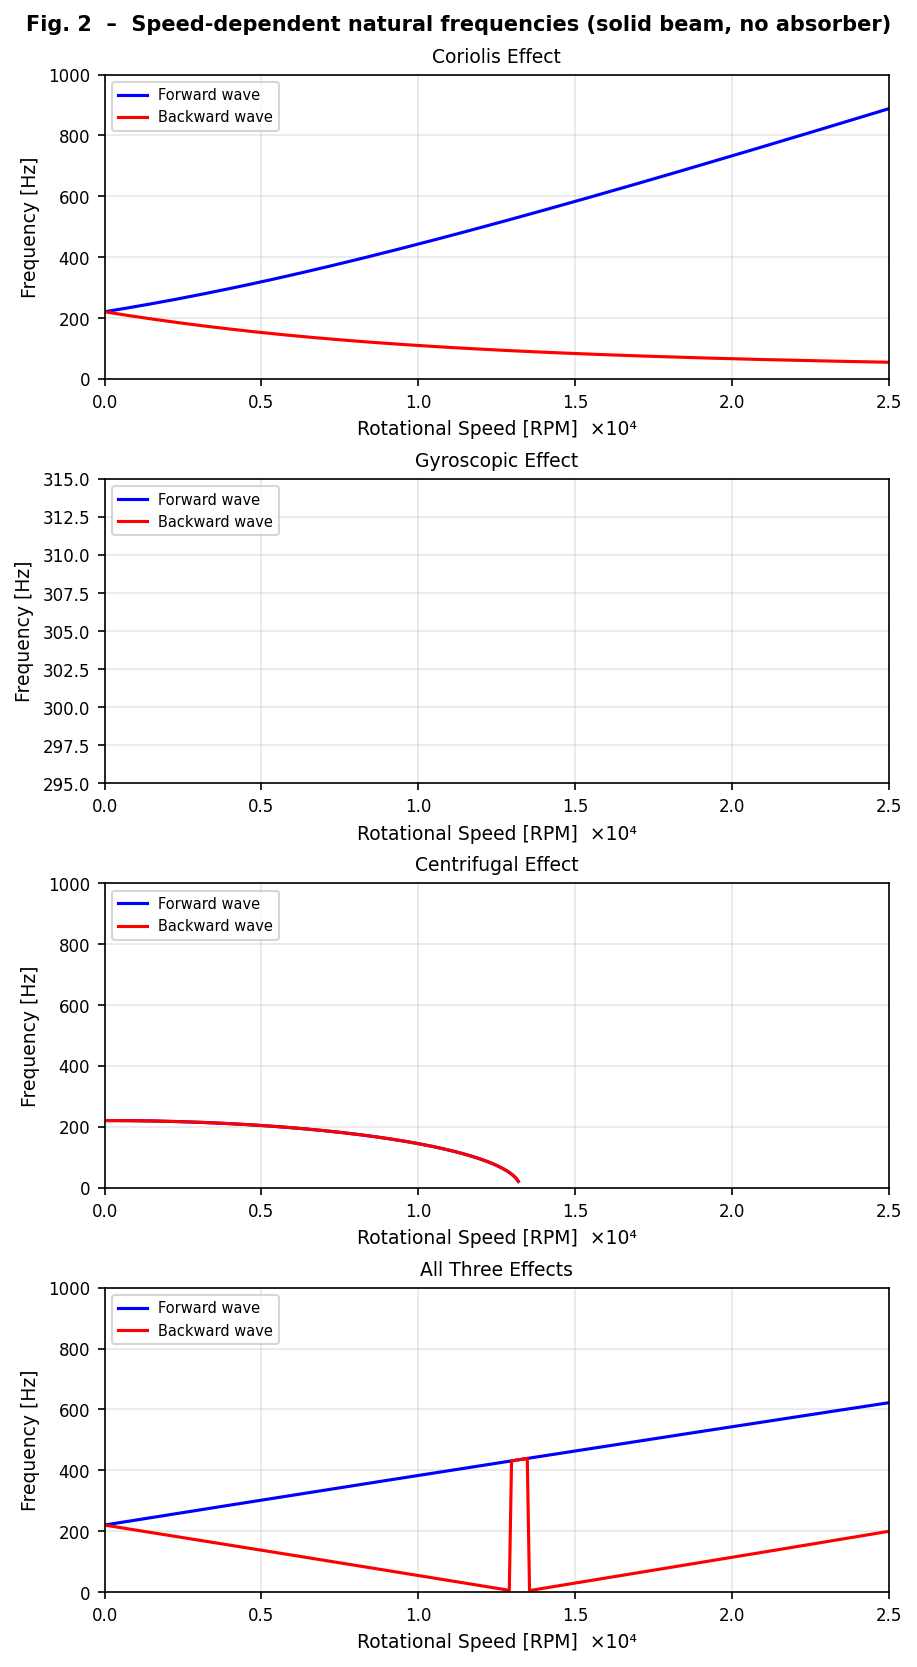

Displayed Fig 2


In [ ]:
fig2, axs2 = plt.subplots(4,1, figsize=(6,11), constrained_layout=True)
fig2.suptitle('Fig. 2  –  Speed-dependent natural frequencies (solid beam, no absorber)', fontsize=10, fontweight='bold')
spd_k = speeds_fig2/1e4
datasets2 = [(f_cor,'Coriolis Effect',(0,1000)),
             (f_gyro,'Gyroscopic Effect',(295,315)),
             (f_cent,'Centrifugal Effect',(0,1000)),
             (f_all,'All Three Effects',(0,1000))]
for ax, (fdata, title, ylim) in zip(axs2, datasets2):
    fw, bw = extract_fw_bw(fdata, ylim[0]+0.5, ylim[1])
    ax.plot(spd_k, fw, 'b-', lw=1.5, label='Forward wave')
    ax.plot(spd_k, bw, 'r-', lw=1.5, label='Backward wave')
    ax.set_xlim(0,2.5); ax.set_ylim(ylim)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Rotational Speed [RPM]  ×10⁴')
    ax.set_ylabel('Frequency [Hz]')
    ax.legend(fontsize=7, loc='upper left'); ax.grid(True, alpha=0.3)
plt.show(); print("Displayed Fig 2")

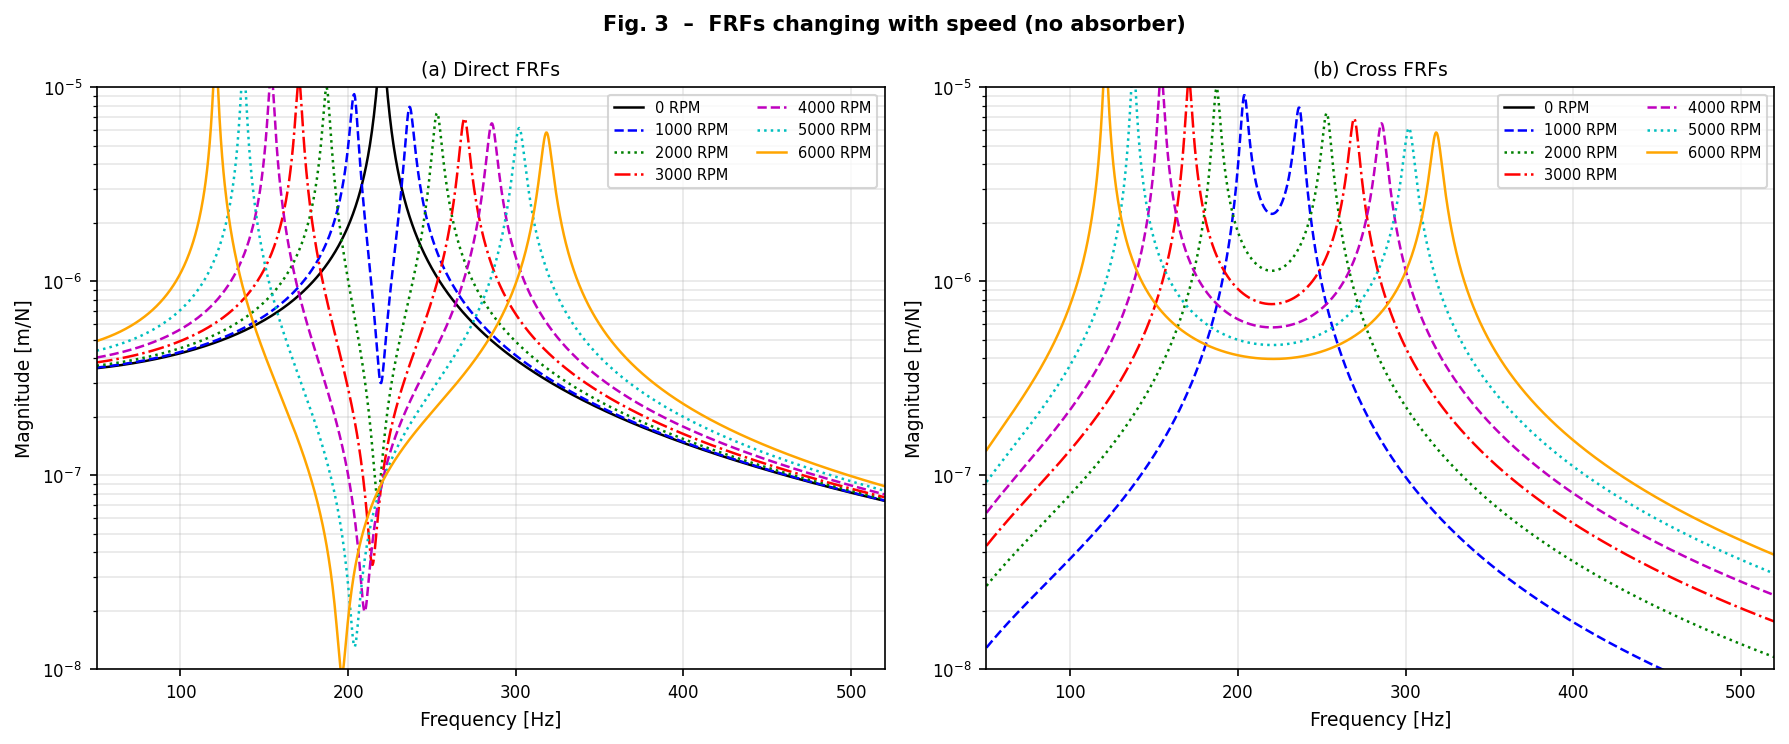

Displayed Fig 3


In [ ]:
fig3, (ax3a,ax3b) = plt.subplots(1,2,figsize=(12,5))
fig3.suptitle('Fig. 3  –  FRFs changing with speed (no absorber)', fontsize=10, fontweight='bold')
clrs3=['k','b','g','r','m','c','orange']
ls3=['-','--',':','-.','--',':','-']
lbls3=[f'{r} RPM' for r in speeds_fig3]
for i,(Hd,Hc) in enumerate(zip(FRF_d_noabs,FRF_c_noabs)):
    ax3a.semilogy(freqs_frf,np.clip(Hd,1e-9,None),color=clrs3[i],ls=ls3[i],lw=1.2,label=lbls3[i])
    ax3b.semilogy(freqs_frf,np.clip(Hc,1e-9,None),color=clrs3[i],ls=ls3[i],lw=1.2,label=lbls3[i])
for ax,t in [(ax3a,'(a) Direct FRFs'),(ax3b,'(b) Cross FRFs')]:
    ax.set_xlim(50,520); ax.set_ylim(1e-8,1e-5)
    ax.set_xlabel('Frequency [Hz]'); ax.set_ylabel('Magnitude [m/N]')
    ax.set_title(t); ax.legend(fontsize=7,ncol=2); ax.grid(True,which='both',alpha=0.3)
plt.tight_layout()
plt.show(); print("Displayed Fig 3")

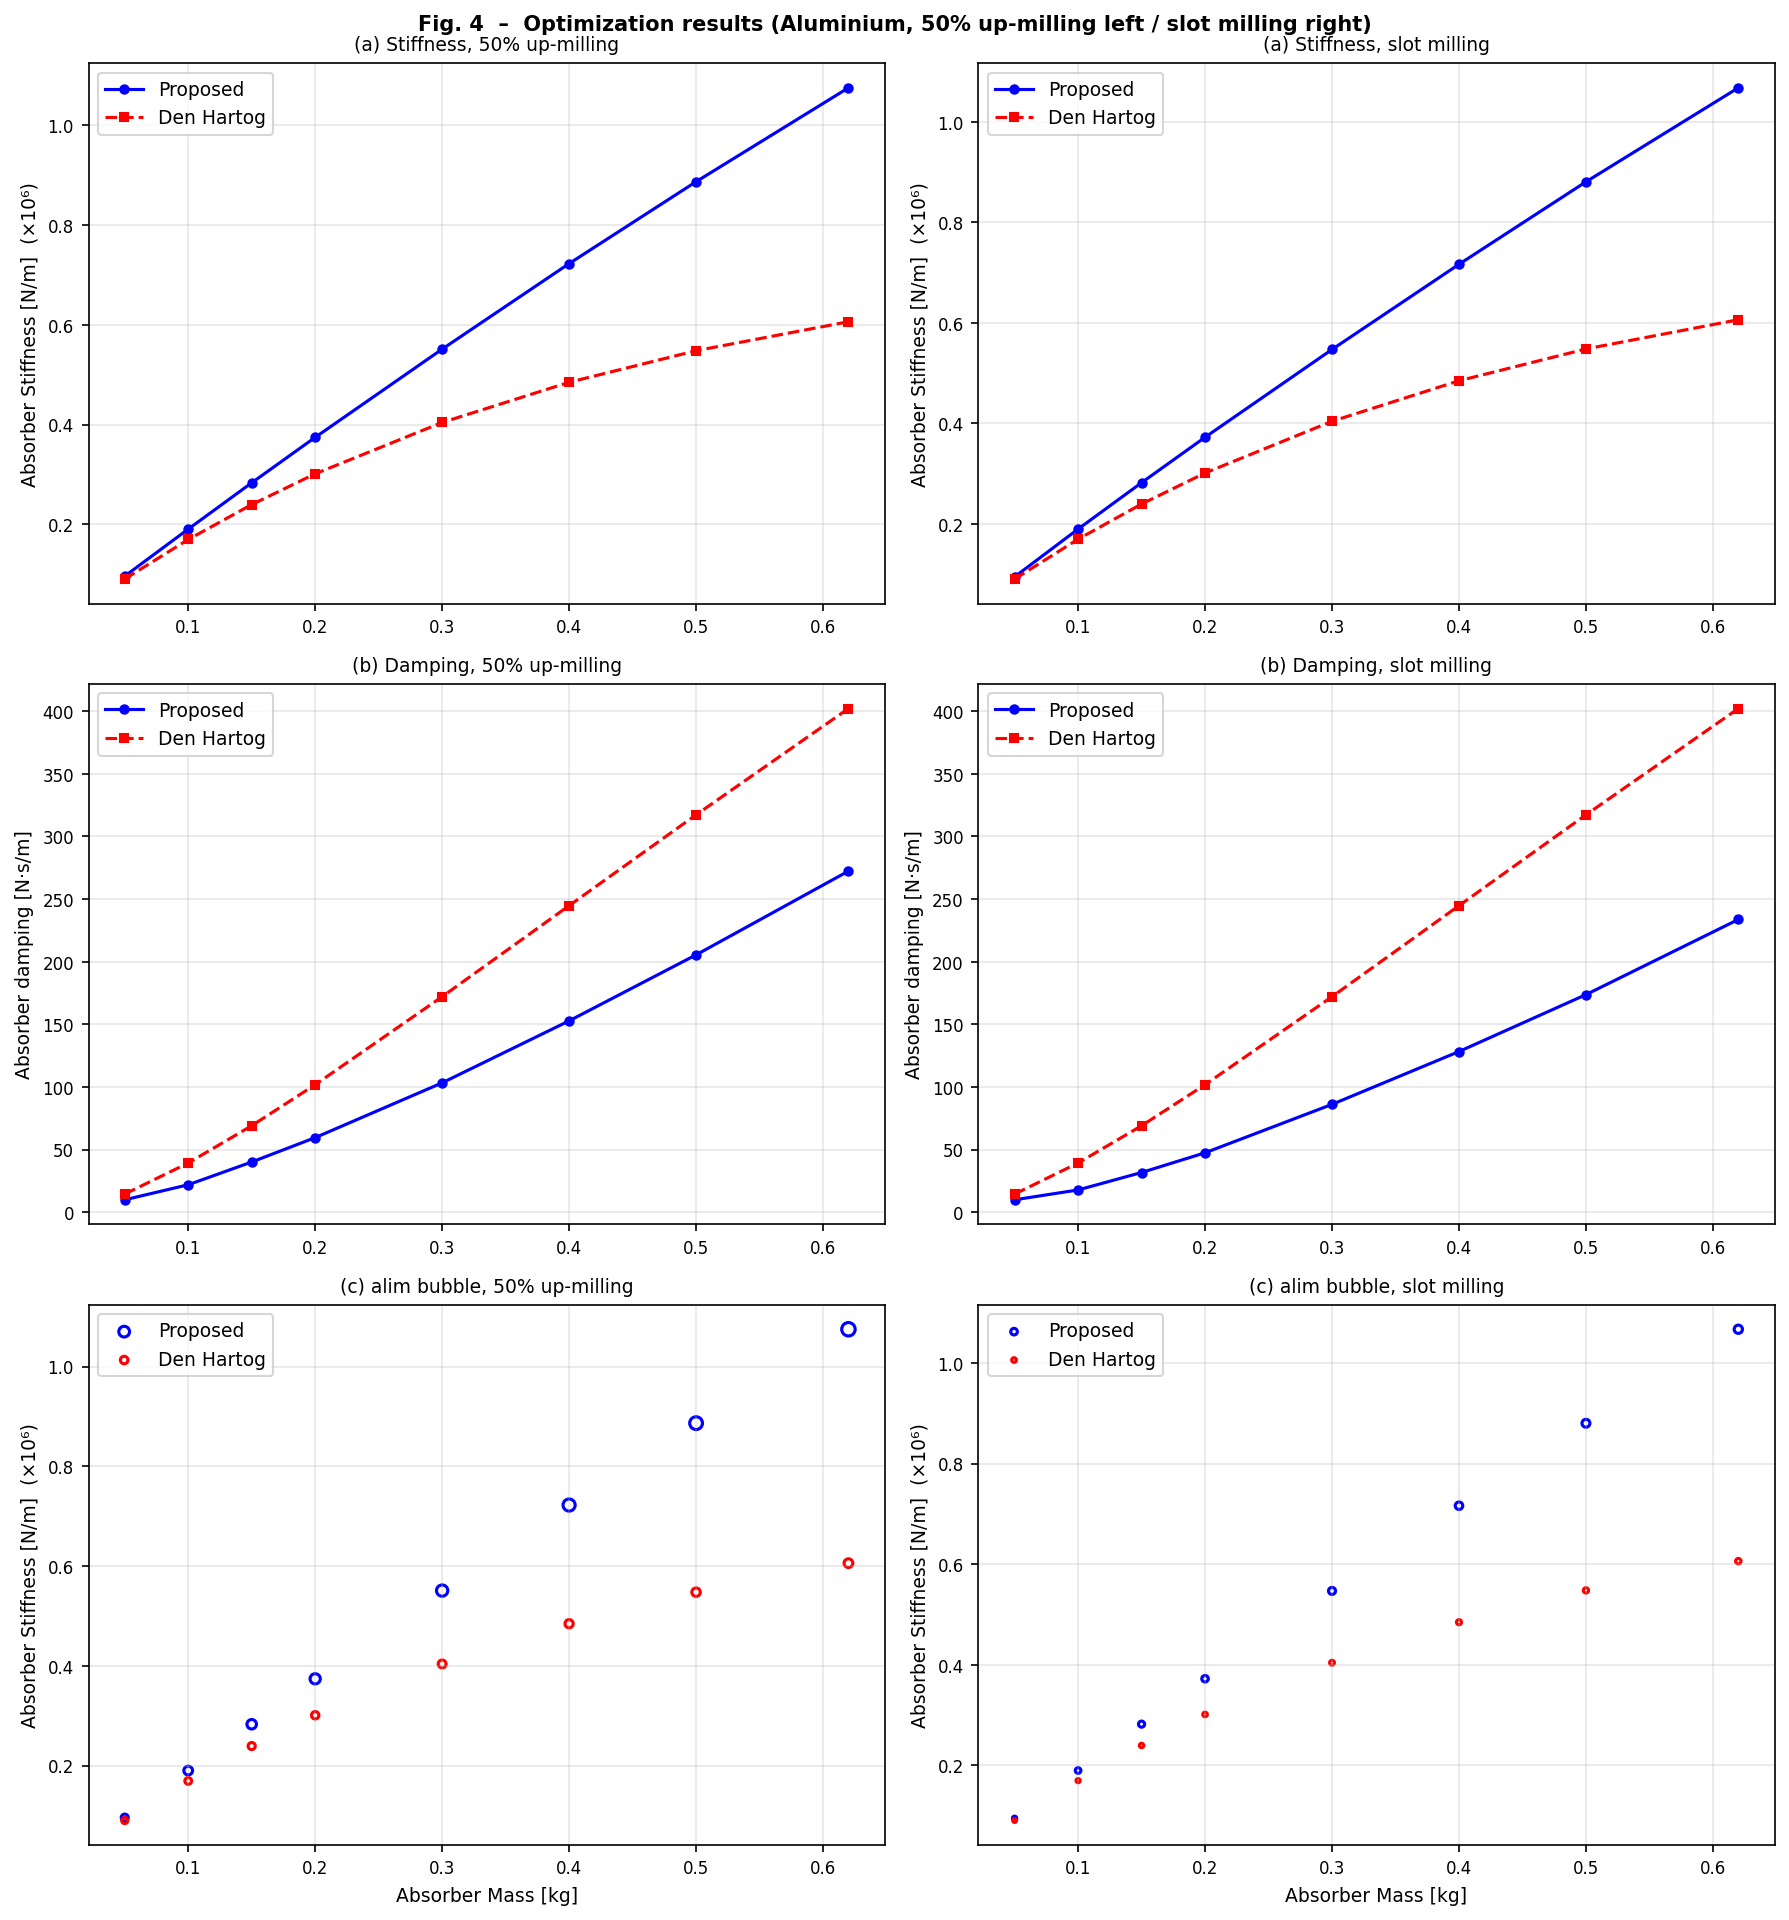

Displayed Fig 4


In [ ]:
fig4, ax4 = plt.subplots(3,2, figsize=(12,13))
fig4.suptitle('Fig. 4  –  Optimization results (Aluminium, 50% up-milling left / slot milling right)',
              fontsize=10, fontweight='bold')
mass_a = np.array(res_up['mass'])
for col, rs in enumerate([res_up, res_sl]):
    # (a) stiffness
    ax4[0,col].plot(rs['mass'], np.array(rs['kd_p'])/1e6, 'b-o', ms=4, label='Proposed')
    ax4[0,col].plot(rs['mass'], np.array(rs['kd_dh'])/1e6, 'r--s', ms=4, label='Den Hartog')
    ax4[0,col].set_ylabel('Absorber Stiffness [N/m]  (×10⁶)')
    ax4[0,col].legend(); ax4[0,col].grid(True, alpha=0.3)
    # (b) damping
    ax4[1,col].plot(rs['mass'], rs['cd_p'], 'b-o', ms=4, label='Proposed')
    ax4[1,col].plot(rs['mass'], np.array(rs['cd_dh']), 'r--s', ms=4, label='Den Hartog')
    ax4[1,col].set_ylabel('Absorber damping [N·s/m]')
    ax4[1,col].legend(); ax4[1,col].grid(True, alpha=0.3)
    # (c) bubble chart alim
    sc1 = ax4[2,col].scatter(rs['mass'], np.array(rs['kd_p'])/1e6,
                              s=np.array(rs['alim_p'])*25, facecolors='none',
                              edgecolors='b', lw=1.5, label='Proposed')
    sc2 = ax4[2,col].scatter(rs['mass'], np.array(rs['kd_dh'])/1e6,
                              s=np.array(rs['alim_dh'])*25, facecolors='none',
                              edgecolors='r', lw=1.5, label='Den Hartog')
    ax4[2,col].set_xlabel('Absorber Mass [kg]')
    ax4[2,col].set_ylabel('Absorber Stiffness [N/m]  (×10⁶)')
    ax4[2,col].legend(); ax4[2,col].grid(True, alpha=0.3)

for ax in ax4[0]:
    ax.set_title(['(a) Stiffness, 50% up-milling','(a) Stiffness, slot milling'][list(ax4[0]).index(ax)])
for ax in ax4[1]:
    ax.set_title(['(b) Damping, 50% up-milling','(b) Damping, slot milling'][list(ax4[1]).index(ax)])
for ax in ax4[2]:
    ax.set_title(['(c) alim bubble, 50% up-milling','(c) alim bubble, slot milling'][list(ax4[2]).index(ax)])
    ax.set_xlabel('Absorber Mass [kg]')
plt.tight_layout()
plt.show(); print("Displayed Fig 4")

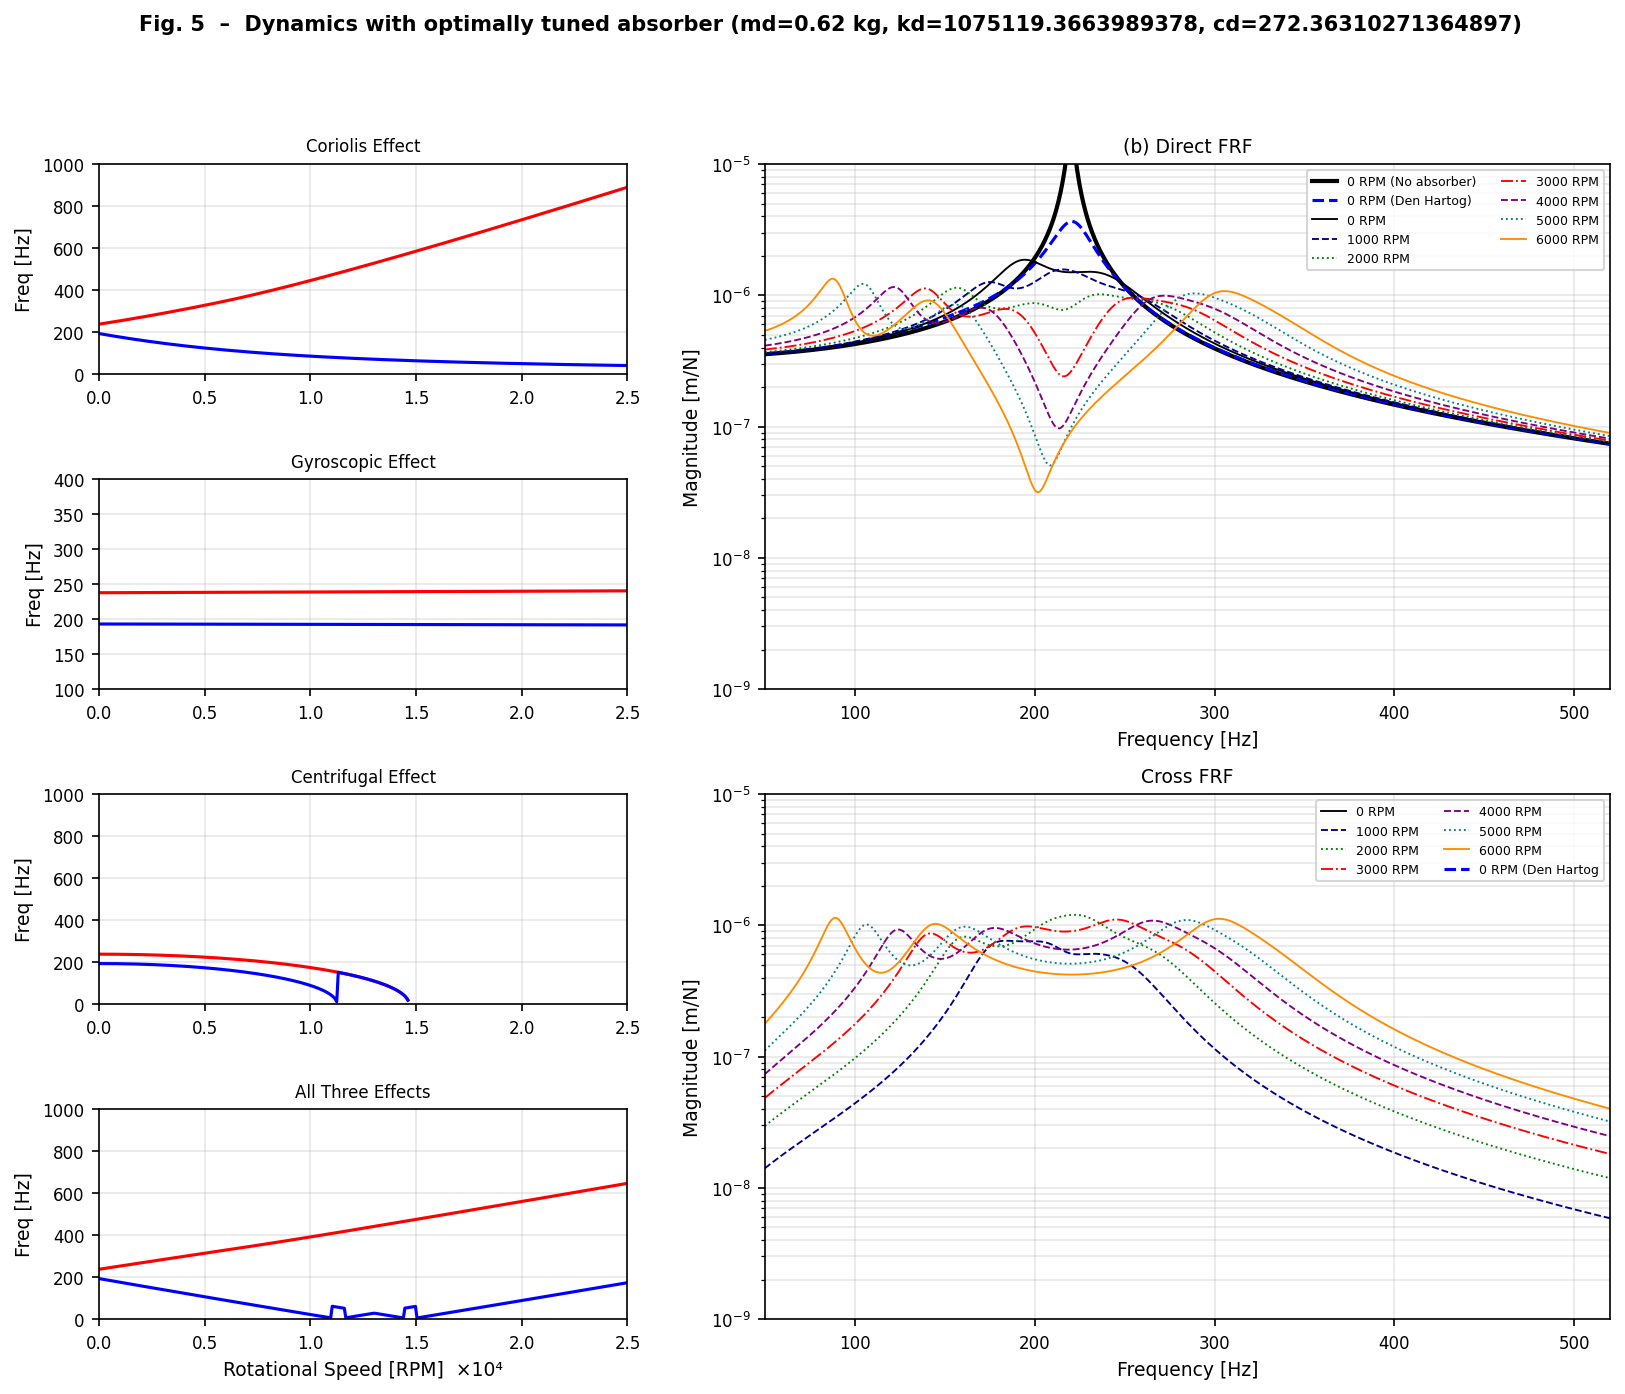

Displayed Fig 5


In [ ]:
fig5 = plt.figure(figsize=(13,10)); fig5.suptitle(f'Fig. 5  –  Dynamics with optimally tuned absorber (md=0.62 kg, kd={kd_opt}, cd={cd_opt})', fontsize=10, fontweight='bold')
gs5 = gridspec.GridSpec(4,2,figure=fig5, width_ratios=[1,1.6], hspace=0.5)
ax5a=fig5.add_subplot(gs5[0,0]); ax5b=fig5.add_subplot(gs5[1,0])
ax5c=fig5.add_subplot(gs5[2,0]); ax5d=fig5.add_subplot(gs5[3,0])
ax5e=fig5.add_subplot(gs5[0:2,1]); ax5f=fig5.add_subplot(gs5[2:4,1])

spd_k5 = speeds_fig5/1e4
for ax,(fdata,title,ylim) in [(ax5a,(f5_cor,'Coriolis Effect',(0,1000))),
                               (ax5b,(f5_gyro,'Gyroscopic Effect',(100,400))),
                               (ax5c,(f5_cent,'Centrifugal Effect',(0,1000))),
                               (ax5d,(f5_all,'All Three Effects',(0,1000)))]:
    fw,bw = extract_fw_bw(fdata,ylim[0]+0.5,ylim[1])
    ax.plot(spd_k5,fw,'r-',lw=1.5); ax.plot(spd_k5,bw,'b-',lw=1.5)
    ax.set_xlim(0,2.5); ax.set_ylim(ylim); ax.set_title(title,fontsize=8)
    ax.set_ylabel('Freq [Hz]'); ax.grid(True,alpha=0.3)
ax5d.set_xlabel('Rotational Speed [RPM]  ×10⁴')

clrs5=['k','darkblue','green','red','purple','teal','darkorange']
ls5=['-','--',':','-.','--',':','-']
ax5e.semilogy(freqs_frf, np.clip(np.abs(Hxx_noabs0),1e-10,None),'k-',lw=2,label='0 RPM (No absorber)')
ax5e.semilogy(freqs_frf, np.clip(np.abs(Hxx_dh0),1e-10,None),'b--',lw=1.5,label='0 RPM (Den Hartog)')
for i,(Hd,Hc) in enumerate(zip(FRF_d_abs,FRF_c_abs)):
    ax5e.semilogy(freqs_frf,np.clip(Hd,1e-10,None),color=clrs5[i],ls=ls5[i],lw=0.9,label=f'{speeds_fig3[i]} RPM')
    ax5f.semilogy(freqs_frf,np.clip(Hc,1e-10,None),color=clrs5[i],ls=ls5[i],lw=0.9,label=f'{speeds_fig3[i]} RPM')
ax5f.semilogy(freqs_frf,np.clip(np.abs(Hxy_dh0),1e-10,None),'b--',lw=1.5,label='0 RPM (Den Hartog')
for ax,t in [(ax5e,'(b) Direct FRF'),(ax5f,'Cross FRF')]:
    ax.set_xlim(50,520); ax.set_ylim(1e-9,1e-5)
    ax.set_xlabel('Frequency [Hz]'); ax.set_ylabel('Magnitude [m/N]')
    ax.set_title(t,fontsize=9); ax.legend(fontsize=6,ncol=2); ax.grid(True,which='both',alpha=0.3)
plt.show(); print("Displayed Fig 5")

#Stability DOC Plot

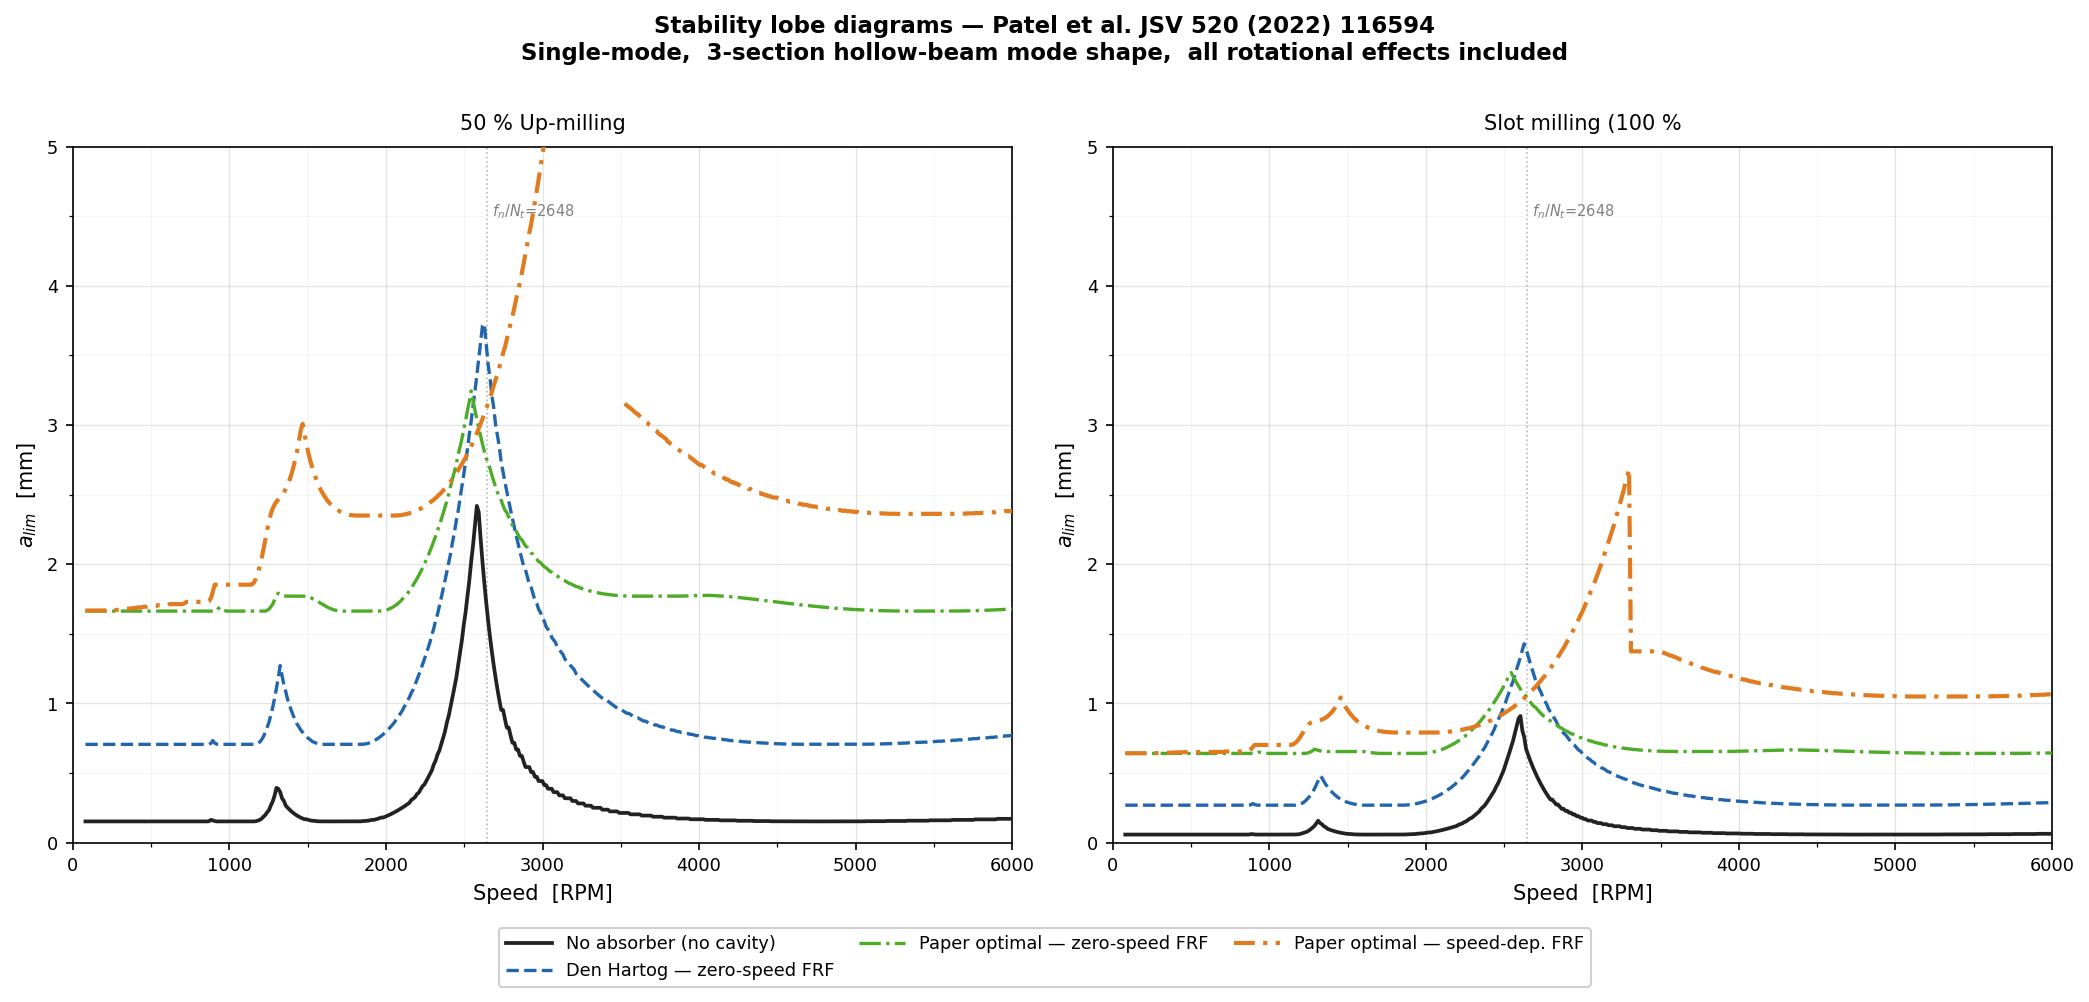


Saved → stability_lobes_correct.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 12. MAIN FIGURE — stability lobe diagrams (replicates paper Fig. 6)
# ═══════════════════════════════════════════════════════════════════════════

# Update matplotlib parameters for better plot aesthetics and readability.
plt.rcParams.update({
    "font.family"   : "DejaVu Sans",
    "font.size"     : 9,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "lines.linewidth": 1.8,
    "figure.dpi"    : 150,
})

# Create a figure with two subplots (1 row, 2 columns) for up-milling and slot milling.
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# Add a main title for the entire figure, explaining the content.
fig.suptitle(
    "Stability lobe diagrams — Patel et al. JSV 520 (2022) 116594\n"
    "Single-mode,  3-section hollow-beam mode shape,  all rotational effects included",
    fontsize=11, fontweight="bold", y=1.01
)

# Define the data to be plotted in each subplot: axes, envelope list, and title.
plot_data = [(axes[0], env_up,   "50 % Up-milling"),
             (axes[1], env_slot, "Slot milling (100 %")]

# Iterate through the plot data to configure and draw each subplot.
for ax, env_list, title in plot_data:
    # Loop through each envelope (stability curve) for the current milling case.
    for i, env in enumerate(env_list):
        # Plot the stability lobe curve using previously defined styles and labels.
        ax.plot(N_grid, env,
                color   = COLORS[i],
                linestyle = LS[i],
                linewidth = LW[i],
                zorder  = ZORDER[i],
                label   = LABELS[i])

    # Set x and y-axis limits for the current subplot.
    ax.set_xlim(0, 6000)
    ax.set_ylim(0, 5.0)
    # Set x and y-axis labels.
    ax.set_xlabel("Speed  [RPM]", fontsize=10)
    ax.set_ylabel("$a_{lim}$  [mm]", fontsize=10)
    # Set the title for the current subplot (e.g., '50 % Up-milling').
    ax.set_title(title, fontsize=10, pad=8)
    # Configure major and minor tick locators for the x-axis.
    ax.xaxis.set_major_locator(plt.MultipleLocator(1000))
    ax.xaxis.set_minor_locator(plt.MultipleLocator(500))
    # Configure major and minor tick locators for the y-axis.
    ax.yaxis.set_major_locator(plt.MultipleLocator(1))
    ax.yaxis.set_minor_locator(plt.MultipleLocator(0.5))
    # Add a grid to the subplot for better readability, distinguishing major and minor lines.
    ax.grid(True, which="major", alpha=0.35, linewidth=0.6)
    ax.grid(True, which="minor", alpha=0.15, linewidth=0.4)

    # Add a vertical line to indicate the natural frequency reference.
    ax.axvline(60*fn1/Nt, color="gray", ls=":", lw=0.8, alpha=0.55)
    # Add text annotation for the natural frequency reference line.
    ax.text(60*fn1/Nt + 30, 4.6, f"$f_n/N_t$={60*fn1/Nt:.0f}",
            fontsize=7, color="gray", va="top")

# Create custom legend handles to display below the subplots.
handles = [plt.Line2D([0], [0], color=COLORS[i], linestyle=LS[i],
                       linewidth=LW[i], label=LABELS[i])
           for i in range(4)]
# Place a shared legend at the bottom center of the figure.
fig.legend(handles=handles,
           loc="lower center",
           ncol=3,
           fontsize=8.5,
           framealpha=0.92,
           bbox_to_anchor=(0.5, -0.08),
           columnspacing=1.4,
           handlelength=2.6)

# Adjust layout to prevent labels from overlapping.
plt.tight_layout()
# Display the generated plot.
plt.show()

# Print a message indicating the saving of the figure.
print("\nSaved → stability_lobes_correct.png")

Max x-relative: ft=162.0Hz, RPM=1945


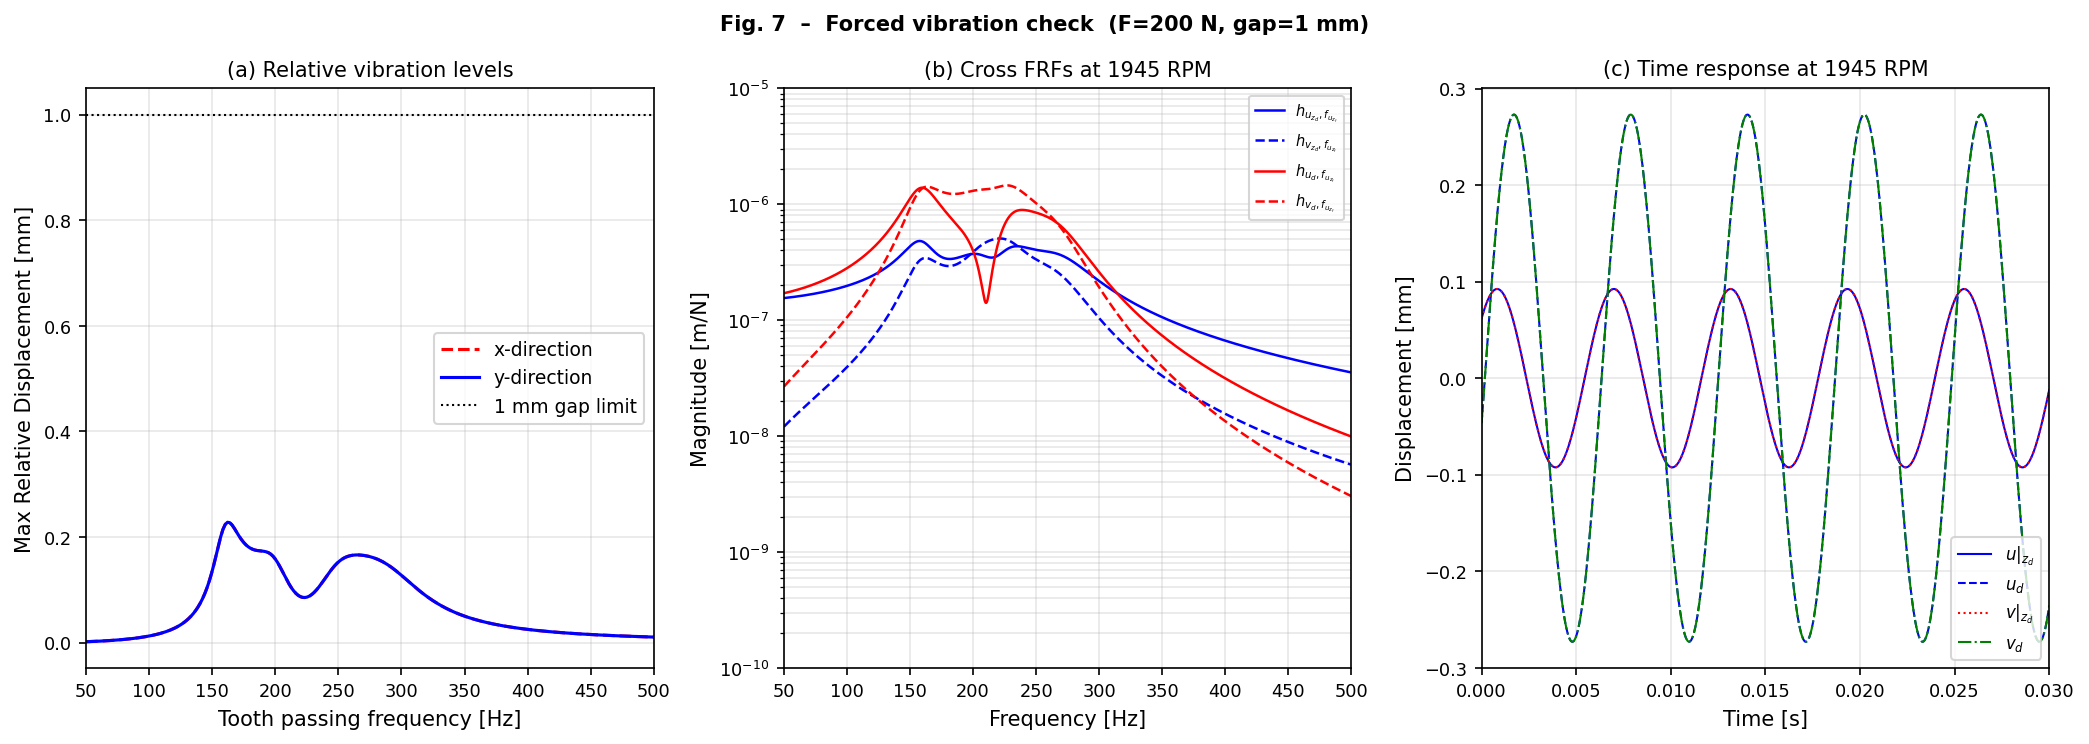

Displayed Fig 7


In [ ]:
fig7, ax7 = plt.subplots(1,3,figsize=(14,5))
fig7.suptitle('Fig. 7  –  Forced vibration check  (F=200 N, gap=1 mm)', fontsize=10, fontweight='bold')

ax7[0].plot(freq_tooth, rel_x_arr,'r--',lw=1.5,label='x-direction')
ax7[0].plot(freq_tooth, rel_y_arr,'b-',lw=1.5,label='y-direction')
ax7[0].axhline(1.0,color='k',ls=':',lw=1,label='1 mm gap limit')
ax7[0].set_xlabel('Tooth passing frequency [Hz]')
ax7[0].set_ylabel('Max Relative Displacement [mm]')
ax7[0].set_title('(a) Relative vibration levels')
ax7[0].legend(); ax7[0].grid(True,alpha=0.3); ax7[0].set_xlim(50,500)

# Cross FRFs at speed of max x-relative
idx_mx = np.argmax(rel_x_arr); ft_mx = freq_tooth[idx_mx]
rpm_mx = ft_mx*60/Nt; Omega_mx = rpm_mx*2*np.pi/60
print(f"Max x-relative: ft={ft_mx:.1f}Hz, RPM={rpm_mx:.0f}")

M,D,K = build_matrices(Omega_mx, with_absorber=True, kd=kd_opt, cd=cd_opt, md_=md)
H_all = np.zeros((4, len(freqs_frf)), dtype=complex)
for k,f in enumerate(freqs_frf):
    w=2*np.pi*f; Z=-w**2*M+1j*w*D+K
    try:
        H = np.linalg.solve(Z, np.eye(4))
        # x force at free end: affects [0,1,2,3] via col 0 of H
        H_all[0,k] = PSI_zd*H[0,0]*PSI_zf   # u_zd / f_x
        H_all[1,k] = PSI_zd*H[2,0]*PSI_zf   # v_zd / f_x  (cross direction)
        H_all[2,k] = H[1,0]*PSI_zf           # u_d / f_x
        H_all[3,k] = H[3,0]*PSI_zf           # v_d / f_x
    except: pass

labels_h = [r'$h_{u_{z_d},f_{u_{z_f}}}$', r'$h_{v_{z_d},f_{u_{z_f}}}$',
            r'$h_{u_d,f_{u_{z_f}}}$',      r'$h_{v_d,f_{u_{z_f}}}$']
clr_h=['b','b','r','r']; ls_h=['-','--','-','--']
for i in range(4):
    ax7[1].semilogy(freqs_frf, np.clip(np.abs(H_all[i]),1e-10,None),
                    color=clr_h[i],ls=ls_h[i],lw=1.2,label=labels_h[i])
ax7[1].set_xlabel('Frequency [Hz]'); ax7[1].set_ylabel('Magnitude [m/N]')
ax7[1].set_title(f'(b) Cross FRFs at {rpm_mx:.0f} RPM')
ax7[1].legend(fontsize=7); ax7[1].grid(True,which='both',alpha=0.3)
ax7[1].set_xlim(50,500); ax7[1].set_ylim(1e-10,1e-5)

# Time response at two critical speeds
t_end=0.03; t=np.linspace(0,t_end,1000)
for splot, (ft, label) in enumerate([(ft_mx, f'{rpm_mx:.0f} RPM'),
                                       (freq_tooth[np.argmax(rel_y_arr)], f'{freq_tooth[np.argmax(rel_y_arr)]*60/Nt:.0f} RPM')]):
    if splot == 0:
        rpm_s=ft*60/Nt; Omega_s=rpm_s*2*np.pi/60
        M,D,K = build_matrices(Omega_s, with_absorber=True, kd=kd_opt, cd=cd_opt, md_=md)
        w=2*np.pi*ft; Z=-w**2*M+1j*w*D+K
        fx=np.array([PSI_zf*F0,0,0,0],dtype=complex)
        fy=np.array([0,0,PSI_zf*F0,0],dtype=complex)
        try:
            qx=np.linalg.solve(Z,fx); qy=np.linalg.solve(Z,fy)
        except:
            qx=qy=np.zeros(4,dtype=complex)
        u_zd = np.real(PSI_zd*qx[0]*np.exp(1j*w*t))*1000
        ud_t = np.real(qx[1]*np.exp(1j*w*t))*1000
        v_zd = np.real(PSI_zd*qy[2]*np.exp(1j*w*t))*1000
        vd_t = np.real(qy[3]*np.exp(1j*w*t))*1000
        ax7[2].plot(t,u_zd,'b-',lw=1,label=r'$u|_{z_d}$'
)
        ax7[2].plot(t,ud_t,'b--',lw=1,label=r'$u_d$')
        ax7[2].plot(t,v_zd,'r:',lw=1,label=r'$v|_{z_d}$'
)
        ax7[2].plot(t,vd_t,'g-.',lw=1,label=r'$v_d$')
        ax7[2].set_xlabel('Time [s]'); ax7[2].set_ylabel('Displacement [mm]')
        ax7[2].set_title(f'(c) Time response at {rpm_s:.0f} RPM')
        ax7[2].legend(fontsize=8); ax7[2].grid(True,alpha=0.3)
        ax7[2].set_xlim(0,0.03)

plt.tight_layout()
plt.show()
print("Displayed Fig 7")

In [ ]:
print("\n=== ALL FIGURES DISPLAYED ===")
print(f"fn1 = {fn1:.2f} Hz  (paper: 306 Hz)")
print(f"Mm  = {Mm:.4f} kg  (paper: 1.4146 kg)")
idx62 = list(mass_range).index(0.62) if 0.62 in mass_range else -1
if idx62 >= 0:
    print(f"At md=0.62: kd_proposed={res_up['kd_p'][idx62]:.2e} (paper: 2.1e6)")
    print(f"            cd_proposed={res_up['cd_p'][idx62]:.1f} (paper: 444)")


=== ALL FIGURES DISPLAYED ===
fn1 = 220.67 Hz  (paper: 306 Hz)
Mm  = 1.5413 kg  (paper: 1.4146 kg)
At md=0.62: kd_proposed=1.08e+06 (paper: 2.1e6)
            cd_proposed=272.4 (paper: 444)
